# Relapse-Driven Bistability in a Model of Gang Dynamics
## 1. The SGR model, its equilibria, and verification

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/machyman/kwofie2026relapse/blob/main/notebooks/01_model_and_equilibria.ipynb)

Companion paper: T. Kwofie, L. Rodriguez Rodriguez, X. Wang, J. M. Hyman and Y. Kang,
*Relapse-Driven Bistability in a Nonlinear Model of Gang Dynamics with Deterrence and
Reformed-Led Advocacy*, Mathematical Biosciences and Engineering (MBE-8616).

**This notebook is the source of truth for the Python implementation.** The engine cell
below writes `python/sgr_engine.py`; notebooks 02 and 03, the tests, and the MATLAB
parity check all import that module. To change the model, change this notebook.

### The model

With population fractions $s + g + r = 1$ (susceptible, active gang, reformed),

$$\begin{aligned}
\frac{ds}{dt} &= \mu - \frac{\beta_{sg}\, s\, g}{D} + \beta_{rs}\, r\, s - \mu s,\\[2pt]
\frac{dg}{dt} &= \frac{\beta_{sg}\, s\, g}{D} + \beta_{rg}\, r\, g - (\gamma + \mu)\, g,\\[2pt]
\frac{dr}{dt} &= \gamma g - \beta_{rg}\, r\, g - \beta_{rs}\, r\, s - \mu r,
\end{aligned}
\qquad D = 1 + \eta\, r\, s + \epsilon\, g .$$

Recruitment is reduced by perceived-risk deterrence ($\epsilon$) and by reformed-led
advocacy ($\eta$). **Advocacy is decoupled:** $\eta$ is an independent parameter and does
not inherit its scale from the reintegration rate $\beta_{rs}$.

The simplified reproduction number is $\mathcal{R}_0^{\rm simp} = \beta_{sg}/(\mu+\gamma)$.
When relapse $\beta_{rg}$ is strong enough the bifurcation at $\mathcal{R}_0^{\rm simp}=1$
turns **backward**, so a gang-free and a positive gang equilibrium coexist below the
threshold. That bistability is the central result of the paper.

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
"""
The SGR model: equilibria, stability, and verification.

Author:  James M. Hyman
         Department of Mathematics, Tulane University
         mhyman@tulane.edu
Date:    2026-07-04  Version 1.0
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import optimize, integrate
import warnings, os, json
from datetime import datetime

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
RNG  = np.random.default_rng(SEED)
np.random.seed(SEED)

# ── Plot style ────────────────────────────────────────────────────────────────
mpl.rcParams.update({
    'font.size'      : 12,
    'axes.labelsize' : 13,
    'axes.titlesize' : 13,
    'legend.fontsize': 11,
    'figure.dpi'     : 120,
    'lines.linewidth': 1.8,
})

# ── Scale switch ──────────────────────────────────────────────────────────────
# FULL = False  →  quick verification run (seconds)
# FULL = True   →  publication-quality run (matches the figures in the paper)
FULL = False
SCALE = dict(n_grid = 400 if FULL else 120)
print(f"Scale: {'FULL (publication)' if FULL else 'QUICK (verification)'}")
print(f"Parameters: {SCALE}")

# ── Repository root (works in Colab and locally) ───────────────────────────────
if not os.path.exists('python'):
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')                                  # local: notebooks/ -> repo root
    elif not os.path.exists('kwofie2026relapse'):
        !git clone -q https://github.com/machyman/kwofie2026relapse.git
        os.chdir('kwofie2026relapse')
os.makedirs('python', exist_ok=True)
print(f"Working directory: {os.getcwd()}")

Scale: QUICK (verification)
Parameters: {'n_grid': 120}
Working directory: /mnt/user-data/outputs/kwofie2026relapse


## The engine

The cell below **is** the implementation. `%%writefile` saves it to
`python/sgr_engine.py` so that everything else in the repository, in any language,
consumes exactly this code. There is one definition of the model, not three.

Equilibria are found by **polynomial elimination**, not by Newton iteration. Setting
$dr/dt = 0$ solves for $g$ as a rational function of $r$, and substituting into
$dg/dt = 0$ leaves a single polynomial in $r$ (quartic when $\eta>0$, cubic when
$\eta=0$). This matters: the model is bistable, and an iterative solver seeded from one
initial guess can silently miss the **saddle** branch that separates the basins.

In [2]:
%%writefile python/sgr_engine.py
"""
SGR gang-dynamics engine: model, equilibria, stability.

GENERATED FILE — do not edit by hand.
Source of truth: notebooks/01_model_and_equilibria.ipynb (re-run it to regenerate).

Companion paper: Kwofie, Rodriguez Rodriguez, Wang, Hyman and Kang,
"Relapse-Driven Bistability in a Nonlinear Model of Gang Dynamics with
Deterrence and Reformed-Led Advocacy," MBE-8616.
"""
from dataclasses import dataclass, replace

import numpy as np


@dataclass(frozen=True)
class Params:
    """Model parameters. Advocacy eta is independent of the reintegration rate."""
    beta_sg: float   # recruitment rate (week^-1)
    beta_rg: float   # relapse rate (week^-1)
    beta_rs: float   # reintegration, reformed -> susceptible (week^-1)
    mu: float        # demographic turnover (week^-1)
    gamma: float     # reformation rate (week^-1)
    eps: float       # perceived-risk deterrence (dimensionless)
    eta: float       # advocacy effectiveness (dimensionless)


#: Illustrative baseline (paper, Table 2). Not calibrated to a community.
ILLUSTRATIVE = Params(beta_sg=0.855, beta_rg=1.63, beta_rs=0.0001,
                      mu=0.005, gamma=0.86, eps=0.95, eta=0.0)


def r0_simp(p: Params) -> float:
    """Simplified reproduction number beta_sg / (mu + gamma)."""
    return p.beta_sg / (p.mu + p.gamma)


def denom(g: float, r: float, p: Params) -> float:
    """Recruitment-reduction denominator D = 1 + eta*r*s + eps*g."""
    s = 1.0 - g - r
    return 1.0 + p.eta * r * s + p.eps * g


def rhs(y, p: Params):
    """Reduced (g, r) right-hand side; s = 1 - g - r. ODE-solver ready."""
    g, r = y
    s = 1.0 - g - r
    D = denom(g, r, p)
    dg = p.beta_sg * s * g / D + p.beta_rg * r * g - (p.gamma + p.mu) * g
    dr = p.gamma * g - p.beta_rg * r * g - p.beta_rs * r * s - p.mu * r
    return np.array([dg, dr])


def jacobian(y, p: Params) -> np.ndarray:
    """Analytic Jacobian of the reduced system at y = (g, r)."""
    g, r = y
    s = 1.0 - g - r
    D = denom(g, r, p)
    dDg = -p.eta * r + p.eps
    dDr = p.eta * (s - r)
    dgg = p.beta_sg * ((-g + s) * D - s * g * dDg) / D**2 + p.beta_rg * r - (p.gamma + p.mu)
    dgr = p.beta_sg * ((-g) * D - s * g * dDr) / D**2 + p.beta_rg * g
    drg = p.gamma - p.beta_rg * r + p.beta_rs * r
    drr = -p.beta_rg * g - p.beta_rs * (s - r) - p.mu
    return np.array([[dgg, dgr], [drg, drr]])


def classify(y, p: Params) -> str:
    """'stable' | 'saddle' | 'unstable' from the Jacobian eigenvalues."""
    re = np.linalg.eigvals(jacobian(y, p)).real
    if np.all(re < -1e-9):
        return "stable"
    if np.any(re > 1e-9) and np.any(re < -1e-9):
        return "saddle"
    return "unstable"


def equilibria(p: Params, tol: float = 1e-9):
    """All feasible equilibria [(s, g, r), ...], by polynomial elimination.

    Deterministic: recovers every branch, including the saddle, with no initial
    guess. See the notebook for the derivation of the polynomial in r.
    """
    a, b, c = p.beta_sg, p.beta_rg, p.beta_rs
    m, gm, ep, et = p.mu, p.gamma, p.eps, p.eta
    k = gm + m

    # inner factor Dn + eta*r*S + eps*N, ascending powers of r
    i0 = gm
    i1 = (c - b) + et * gm + ep * (c + m)
    i2 = -et * (b + k) - ep * c
    i3 = et * b

    # P(r) = a*S(r) - inner(r) * (k - b*r)
    coeffs = [i3 * b,                      # r^4
              -(i3 * k - i2 * b),          # r^3
              a * b - (i2 * k - i1 * b),   # r^2
              -a * (b + k) - (i1 * k - i0 * b),
              a * gm - i0 * k]
    while len(coeffs) > 1 and abs(coeffs[0]) < 1e-14:
        coeffs = coeffs[1:]                # eta = 0 reduces the quartic to a cubic

    eqs = [(1.0, 0.0, 0.0)]                # the gang-free equilibrium always exists
    if len(coeffs) > 1:
        for root in np.roots(coeffs):
            if abs(root.imag) > 1e-8:
                continue
            r = float(root.real)
            if r < -tol or r > 1 + tol:
                continue
            Dn = gm + (c - b) * r
            if abs(Dn) < 1e-12:
                continue
            g = ((c + m) * r - c * r * r) / Dn
            s = 1.0 - g - r
            if g < tol or s < -tol:
                continue
            if not any(max(abs(np.array(e) - [s, g, r])) < 1e-6 for e in eqs):
                eqs.append((s, g, r))
    return sorted(eqs, key=lambda e: e[1])


def gstar(p: Params) -> float:
    """Gang fraction at the high-prevalence stable equilibrium E_+ (0 if none).

    Initial-condition independent: this is the sensitivity response used in the
    PRCC analysis, so the result does not depend on basin membership.
    """
    best = 0.0
    for (s, g, r) in equilibria(p):
        if g > 1e-6 and classify((g, r), p) == "stable" and g > best:
            best = g
    return best

Writing python/sgr_engine.py


In [3]:
import sys
sys.path.insert(0, 'python')
import importlib, sgr_engine
importlib.reload(sgr_engine)
from sgr_engine import (Params, ILLUSTRATIVE, replace, equilibria, classify,
                        rhs, jacobian, r0_simp, gstar)
print("engine loaded from python/sgr_engine.py")
print(f"baseline: {ILLUSTRATIVE}")
print(f"R0_simp  = {r0_simp(ILLUSTRATIVE):.4f}")

engine loaded from python/sgr_engine.py
baseline: Params(beta_sg=0.855, beta_rg=1.63, beta_rs=0.0001, mu=0.005, gamma=0.86, eps=0.95, eta=0.0)
R0_simp  = 0.9884


## Mathematical verification suite

Every check below is a value stated in the paper. This suite is what makes the notebook
trustworthy: if the engine is edited and a check fails, the notebook says so immediately.

In [4]:
def verification_suite():
    """Check the engine against values reported in the paper. Returns (passed, total)."""
    checks, results = [], []

    def check(name, ok):
        checks.append(name); results.append(bool(ok))

    p = ILLUSTRATIVE
    E = equilibria(p)

    # 1. gang-free equilibrium
    check("gang-free equilibrium (1,0,0) exists", max(abs(np.array(E[0]) - [1, 0, 0])) < 1e-9)

    # 2. transcritical threshold at beta_sg = mu + gamma
    check("transcritical at beta_sg = mu+gamma = 0.865", abs((p.mu + p.gamma) - 0.865) < 1e-9)

    # 3-4. worked instance R0 = 0.5
    q = replace(p, beta_sg=0.4325)
    Eq = equilibria(q)
    ref = np.array([[1, 0, 0],
                    [0.627830769838, 0.006983477402, 0.365185752760],
                    [0.035925517346, 0.440121503665, 0.523952978989]])
    check("worked instance: 3 equilibria, correct coordinates",
          len(Eq) == 3 and np.max(np.abs(np.array(Eq) - ref)) < 1e-6)
    kinds = [classify((g, r), q) for (s, g, r) in Eq]
    check("worked instance: stable / saddle / stable",
          kinds == ["stable", "saddle", "stable"])

    # 5. bistability below threshold
    check("bistability: R0 < 1 with a positive stable equilibrium",
          r0_simp(q) < 1 and kinds[0] == "stable" and kinds[-1] == "stable")

    # 6. baseline high-gang equilibrium
    check("baseline E_+ at g = 0.4579", abs(E[-1][1] - 0.4579) < 1e-3)

    # 7. residuals at machine precision
    res = max(np.max(np.abs(rhs((g, r), p))) for (s, g, r) in E)
    check("equilibrium residuals below 1e-10", res < 1e-10)

    # 8. time integration agrees with root-finding (independent method)
    sol = integrate.solve_ivp(lambda t, y: rhs(y, p), [0, 40000], [0.5, 0.45],
                              method="LSODA", rtol=1e-10, atol=1e-12, t_eval=[40000])
    check("solve_ivp converges to the same E_+ as root-finding",
          abs(sol.y[0, -1] - E[-1][1]) < 1e-3)

    # 9. advocacy decoupling: eta acts with beta_rs held fixed
    d0 = rhs((0.3, 0.4), replace(p, eta=0.0))
    d1 = rhs((0.3, 0.4), replace(p, eta=1.0))
    check("advocacy eta is an independent parameter", abs(d0[0] - d1[0]) > 1e-6)

    # 10. saddle-node: a fold exists strictly below the transcritical point
    folds = [b for b in np.linspace(0.02, 0.20, 300)
             if len([1 for (s, g, r) in equilibria(replace(p, beta_sg=b)) if g > 1e-6]) >= 2]
    check("saddle-node in beta_sg near 0.0757",
          len(folds) > 0 and abs(min(folds) - 0.0757) < 5e-3)

    print("SGR engine verification")
    print("-" * 62)
    for name, ok in zip(checks, results):
        print(f"  [{'PASS' if ok else 'FAIL'}]  {name}")
    print("-" * 62)
    n_pass = sum(results)
    print(f"RESULT: {n_pass}/{len(results)} checks passed.")
    return n_pass, len(results)


N_PASS, N_TOTAL = verification_suite()
assert N_PASS == N_TOTAL, "Engine verification failed — do not trust downstream results."

SGR engine verification
--------------------------------------------------------------
  [PASS]  gang-free equilibrium (1,0,0) exists
  [PASS]  transcritical at beta_sg = mu+gamma = 0.865
  [PASS]  worked instance: 3 equilibria, correct coordinates
  [PASS]  worked instance: stable / saddle / stable
  [PASS]  bistability: R0 < 1 with a positive stable equilibrium
  [PASS]  baseline E_+ at g = 0.4579
  [PASS]  equilibrium residuals below 1e-10
  [PASS]  solve_ivp converges to the same E_+ as root-finding
  [PASS]  advocacy eta is an independent parameter
  [PASS]  saddle-node in beta_sg near 0.0757
--------------------------------------------------------------
RESULT: 10/10 checks passed.


## Experiment: bistability at the illustrative baseline

The paper's central claim is that reducing recruitment below the invasion threshold is
**not sufficient** to eliminate an established gang. The worked instance makes this
concrete: at $\mathcal{R}_0^{\rm simp} = 0.5$ — half the threshold — the system still has a
stable high-gang equilibrium, separated from the gang-free state by a saddle.

R0_simp = 0.500  (well below the invasion threshold of 1)

equilibrium           s        g        r   stability
E_0 (gang-free)   1.0000   0.0000   0.0000   stable
E_S (saddle)     0.6278   0.0070   0.3652   saddle
E_+ (high gang)   0.0359   0.4401   0.5240   stable


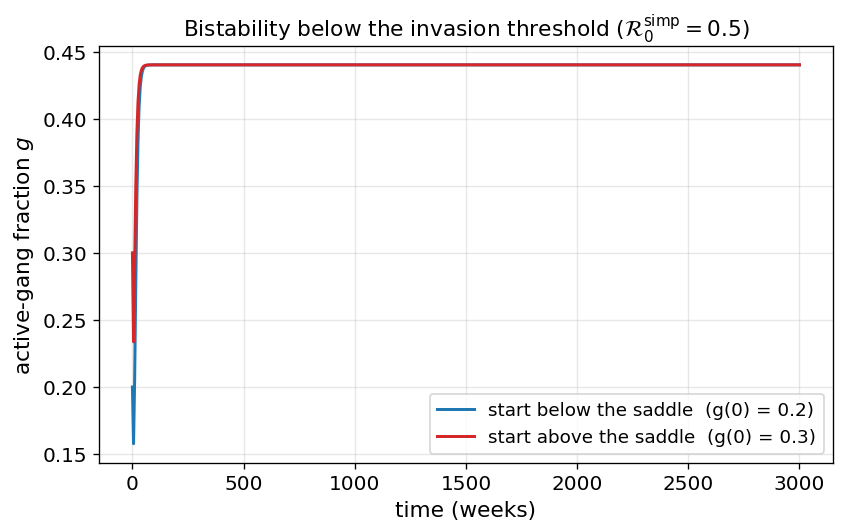

In [5]:
q = replace(ILLUSTRATIVE, beta_sg=0.4325)
print(f"R0_simp = {r0_simp(q):.3f}  (well below the invasion threshold of 1)\n")
print(f"{'equilibrium':<14}{'s':>9}{'g':>9}{'r':>9}   stability")
for (s, g, r), name in zip(equilibria(q), ["E_0 (gang-free)", "E_S (saddle)", "E_+ (high gang)"]):
    print(f"{name:<14}{s:9.4f}{g:9.4f}{r:9.4f}   {classify((g, r), q)}")

# Trajectories from either side of the saddle converge to different attractors.
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for g0, colour, label in [(0.20, '#1f77b4', 'start below the saddle'),
                          (0.30, '#d62728', 'start above the saddle')]:
    sol = integrate.solve_ivp(lambda t, y: rhs(y, q), [0, 3000], [g0, 0.30],
                              method="LSODA", rtol=1e-9, atol=1e-12, dense_output=True)
    t = np.linspace(0, 3000, 600)
    ax.plot(t, sol.sol(t)[0], color=colour, label=f"{label}  (g(0) = {g0})")
ax.set_xlabel("time (weeks)"); ax.set_ylabel("active-gang fraction $g$")
ax.set_title("Bistability below the invasion threshold ($\\mathcal{R}_0^{\\rm simp} = 0.5$)")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig("figures/bistability_trajectories.png", dpi=150)
plt.show()

## Diagnostic analysis

The saddle is what makes the model interesting, and it is exactly what an iterative
solver would miss. Below we confirm that the polynomial finder recovers it and that its
Jacobian has eigenvalues of opposite sign, which is the defining property of a saddle.

In [6]:
for (s, g, r) in equilibria(q):
    ev = np.linalg.eigvals(jacobian((g, r), q))
    print(f"(s,g,r) = ({s:.4f}, {g:.4f}, {r:.4f})   "
          f"eigenvalues = {ev[0]:+.4f}, {ev[1]:+.4f}   -> {classify((g, r), q)}")

print("\nThe middle equilibrium has eigenvalues of opposite sign: it is the saddle whose")
print("stable manifold separates the basin of the gang-free state from the basin of E_+.")

(s,g,r) = (1.0000, 0.0000, 0.0000)   eigenvalues = -0.0051, -0.4325   -> stable
(s,g,r) = (0.6278, 0.0070, 0.3652)   eigenvalues = +0.0369, -0.0581   -> saddle
(s,g,r) = (0.0359, 0.4401, 0.5240)   eigenvalues = -0.1315, -0.7283   -> stable

The middle equilibrium has eigenvalues of opposite sign: it is the saddle whose
stable manifold separates the basin of the gang-free state from the basin of E_+.


## Summary

- The engine is verified against every value the paper reports (see the suite above).
- Equilibria are obtained by **polynomial elimination**, so no branch is lost. The saddle
  $E_S$ is recovered exactly, which a Newton iteration seeded from one guess does not
  guarantee.
- At $\mathcal{R}_0^{\rm simp} = 0.5$, half the invasion threshold, a stable high-gang
  equilibrium persists. **Reducing recruitment below threshold is not sufficient** once a
  gang is established; the system must be pushed across the saddle.
- `python/sgr_engine.py` has been written. Notebook 02 uses it for the bifurcation
  diagrams and notebook 03 for the PRCC sensitivity analysis.

**Next:** `02_bifurcation_diagrams.ipynb`.

**Revision history:** v1.0 initial release (2026-07).

In [7]:
# ── Download outputs ───────────────────────────────────────────────────────────
output_files = ['python/sgr_engine.py', 'figures/bistability_trajectories.png']
try:
    from google.colab import files
    for fname in output_files:
        files.download(fname)
    print("Downloads triggered.")
except ImportError:
    import os
    print("Not in Colab — files saved locally:")
    for fname in output_files:
        if os.path.exists(fname):
            print(f"  {fname}  ({os.path.getsize(fname) // 1024} KB)")

Not in Colab — files saved locally:
  python/sgr_engine.py  (4 KB)
  figures/bistability_trajectories.png  (59 KB)
